# When Your AI Compliance Agent Hallucinates
## Grounding verification for autonomous agents over legal documents

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/groundlens-dev/groundlens/blob/main/examples/eu_ai_act_compliance_agent.ipynb)

---

### The problem

Autonomous AI agents -- Claude Desktop with MCP connectors, LangGraph pipelines, CrewAI crews -- are increasingly used to read enterprise documents and answer questions. When the document is a 144-page regulation like the **EU AI Act (Regulation 2024/1689)**, getting an article number wrong, misquoting a fine amount, or inventing an obligation that doesn't exist has real consequences.

An agent pipeline has two failure modes:

1. **Retrieval failure:** the agent pulls the wrong section of the regulation
2. **Generation failure:** the agent ignores or fabricates from the correct section

Both look identical in the final output: a confident, fluent, wrong answer.

### What groundlens measures

[groundlens](https://groundlens.dev) provides two geometric signals at each pipeline step:

| Metric | What it measures | Catches |
|---|---|---|
| **Retrieval relevance** | Cosine similarity between question and retrieved text | Wrong section pulled |
| **SGI** (Semantic Grounding Index) | Whether the response embedding moved toward the context | LLM ignored or fabricated from context |

Together they cover the full pipeline. No second LLM. No prompt engineering. Pure geometry.

### References

| Paper | Key finding |
|---|---|
| [Marin, "Semantic Grounding Index" (2025)](https://arxiv.org/abs/2512.13771) | Geometric bounds on context engagement in RAG |
| [Marin, "A Geometric Taxonomy of Hallucination" (2026)](https://arxiv.org/abs/2602.13224) | Three hallucination types with distinct geometric signatures |
| [EU AI Act](https://eur-lex.europa.eu/eli/reg/2024/1689/oj) | Regulation (EU) 2024/1689, 13 June 2024 |

## 1. Setup

| Key | Why | Where to get it |
|-----|-----|-----------------|
| **Hugging Face** (`HF_TOKEN`) | Download the sentence-transformer model (~90 MB) | [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens) |

> No OpenAI key needed. This notebook uses hand-crafted responses to demonstrate each failure mode with controlled inputs.

In [1]:
# -- Install --
#!pip install -q groundlens==2026.5.22

In [2]:
# -- API Key --
import os
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
print("HF_TOKEN:", "set" if os.environ.get("HF_TOKEN") else "NOT SET")

HF_TOKEN: set


In [3]:
# -- Imports --
import warnings
import logging
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.patches as mpatches

from groundlens import compute_sgi
from groundlens._internal.embeddings import encode_texts
from groundlens._internal.geometry import cosine_similarity

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*PendingDeprecationWarning.*")
logging.getLogger("groundlens").setLevel(logging.ERROR)
matplotlib.rcParams["font.family"] = "sans-serif"

print("All imports loaded")

All imports loaded


## 2. The EU AI Act Knowledge Base

Four regulation excerpts, each a direct passage from [Regulation (EU) 2024/1689](https://eur-lex.europa.eu/eli/reg/2024/1689/oj). Article numbers, fine amounts, and obligation details are exact.

In [4]:
EU_AI_ACT = {
    "penalties_article_99": (
        "Article 99 -- Fines. "
        "3. Non-compliance with the prohibition of the AI practices referred to "
        "in Article 5 shall be subject to administrative fines of up to "
        "EUR 35 000 000 or, if the offender is an undertaking, up to 7 % of its "
        "total worldwide annual turnover for the preceding financial year, "
        "whichever is higher. "
        "4. Non-compliance of an AI system with any requirements or obligations "
        "under this Regulation, other than those laid down in Article 5, shall be "
        "subject to administrative fines of up to EUR 15 000 000 or, if the "
        "offender is an undertaking, up to 3 % of its total worldwide annual "
        "turnover for the preceding financial year, whichever is higher. "
        "5. The supply of incorrect, incomplete or misleading information to "
        "notified bodies or national competent authorities in reply to a request "
        "shall be subject to administrative fines of up to EUR 7 500 000 or, "
        "if the offender is an undertaking, up to 1 % of its total worldwide "
        "annual turnover for the preceding financial year, whichever is higher."
    ),
    "gpai_obligations_article_53": (
        "Article 53 -- Obligations for providers of general-purpose AI models. "
        "1. Providers of general-purpose AI models shall: "
        "(a) draw up and keep up to date the technical documentation of the model, "
        "including its training and testing process and the results of its "
        "evaluation, which shall contain, at a minimum, the information set out "
        "in Annex XI for the purpose of providing it, upon request, to the "
        "AI Office and the national competent authorities; "
        "(b) draw up, keep up to date and make available information and "
        "documentation to providers of AI systems who intend to integrate the "
        "general-purpose AI model into their AI systems, without prejudice to "
        "the need to observe and protect intellectual property rights; "
        "(c) put in place a policy to comply with Union law on copyright and "
        "related rights, and in particular to identify and comply with a "
        "reservation of rights expressed pursuant to Article 4(3) of "
        "Directive (EU) 2019/790; "
        "(d) draw up and make publicly available a sufficiently detailed summary "
        "about the content used for training of the general-purpose AI model, "
        "according to a template provided by the AI Office."
    ),
    "human_oversight_article_14": (
        "Article 14 -- Human oversight. "
        "1. High-risk AI systems shall be designed and developed in such a way, "
        "including with appropriate human-machine interface tools, that they can "
        "be effectively overseen by natural persons during the period in which "
        "they are in use. "
        "4. The measures referred to in paragraph 1 shall enable the individuals "
        "to whom human oversight is assigned to do the following, as appropriate "
        "to the circumstances: "
        "(a) fully understand the capacities and limitations of the high-risk "
        "AI system and be able to duly monitor its operation; "
        "(b) remain aware of the possible tendency of automatically relying or "
        "over-relying on the output produced by a high-risk AI system; "
        "(c) be able to correctly interpret the high-risk AI system output, "
        "taking into account, for example, the interpretation tools and methods "
        "available; "
        "(d) be able to decide, in any particular situation, not to use the "
        "high-risk AI system or to otherwise disregard, override or reverse "
        "the output of the high-risk AI system; "
        "(e) be able to intervene in the operation of the high-risk AI system "
        "or interrupt the system through a stop button or a similar procedure "
        "that allows the system to come to a halt in a safe state."
    ),
    "gpai_systemic_risk_article_51": (
        "Article 51 -- Classification of general-purpose AI models as "
        "general-purpose AI models with systemic risk. "
        "1. A general-purpose AI model shall be classified as a general-purpose "
        "AI model with systemic risk if it meets any of the following conditions: "
        "(a) it has high impact capabilities evaluated on the basis of appropriate "
        "technical tools and methodologies, including indicators and benchmarks; "
        "(b) based on a decision of the Commission, having regard to the criteria "
        "set out in Annex XIII, it has capabilities or an impact equivalent to "
        "those set out in point (a). "
        "2. A general-purpose AI model shall be presumed to have high impact "
        "capabilities pursuant to paragraph 1, point (a), when the cumulative "
        "amount of computation used for its training measured in floating point "
        "operations is greater than 10^25."
    ),
}

print(f"Knowledge base: {len(EU_AI_ACT)} regulation excerpts")
for key in EU_AI_ACT:
    print(f"  {key}: {len(EU_AI_ACT[key])} chars")

Knowledge base: 4 regulation excerpts
  penalties_article_99: 1002 chars
  gpai_obligations_article_53: 1118 chars
  human_oversight_article_14: 1198 chars
  gpai_systemic_risk_article_51: 809 chars


## 3. Retrieval Relevance

Before measuring whether the LLM grounded in the context (SGI), we measure whether the retriever pulled the *right* context. Retrieval relevance is the cosine similarity between the question and retrieved text embeddings.

A low relevance score means the retriever pulled the wrong section -- and everything downstream is compromised no matter how well-grounded the LLM response is.

In [5]:
def retrieval_relevance(question, context):
    embs = encode_texts([question, context])
    return round(cosine_similarity(embs[0], embs[1]), 4)

# Quick test
rel = retrieval_relevance(
    "What fines apply to prohibited AI practices?",
    EU_AI_ACT["penalties_article_99"]
)
print(f"Relevance (fines question vs Article 99): {rel:.4f}")

rel_wrong = retrieval_relevance(
    "What fines apply to prohibited AI practices?",
    EU_AI_ACT["gpai_systemic_risk_article_51"]
)
print(f"Relevance (fines question vs Article 51): {rel_wrong:.4f}")
print(f"Difference: {rel - rel_wrong:.4f}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Relevance (fines question vs Article 99): 0.7438
Relevance (fines question vs Article 51): 0.4464
Difference: 0.2974


## 4. Case 1 -- Grounded: Correct penalty citation

**Scenario:** A compliance officer asks about fines for prohibited AI practices. The retriever pulls Article 99 (correct). The analyzer cites the right EUR amounts, percentages, and article references.

**Expected:** High relevance (right section retrieved) + high SGI (response engages the text).

In [6]:
Q1 = "What fines apply to companies that deploy prohibited AI practices under the EU AI Act?"
C1 = EU_AI_ACT["penalties_article_99"]
R1 = (
    "Under Article 99(3) of the EU AI Act, non-compliance with the "
    "prohibited AI practices defined in Article 5 is subject to "
    "administrative fines of up to EUR 35 million or 7% of the "
    "company's total worldwide annual turnover, whichever is higher. "
    "This is the most severe tier. The regulation also establishes "
    "two lower tiers: up to EUR 15 million or 3% for other "
    "non-compliance (Article 99(4)), and up to EUR 7.5 million "
    "or 1% for supplying incorrect information (Article 99(5))."
)

rel_1 = retrieval_relevance(Q1, C1)
sgi_1 = compute_sgi(question=Q1, context=C1, response=R1)

print(f"Retrieval relevance: {rel_1:.4f}")
print(f"SGI: {sgi_1.value:.3f} ({'flagged' if sgi_1.flagged else 'passed'})")
print(f"Explanation: {sgi_1.explanation}")

Retrieval relevance: 0.7363
SGI: 1.269 (passed)
Explanation: SGI=1.269 — strong context engagement (pass)


## 5. Case 2 -- Hallucinated: Fabricated GPAI obligations

**Scenario:** A deployment manager asks about GPAI provider obligations. The retriever pulls Article 53 (correct). But the LLM fabricates: mandatory EU AI Registry registration, annual stress testing, quarterly transparency reports, an AI Safety Officer. None of these exist in Article 53.

**Expected:** High relevance (right section) + low SGI (response doesn't engage the actual text).

In [7]:
Q2 = "What are the specific obligations for providers of general-purpose AI models under the EU AI Act?"
C2 = EU_AI_ACT["gpai_obligations_article_53"]
R2 = (
    "Under the EU AI Act, providers of general-purpose AI models must "
    "register all models with the EU AI Registry within 90 days of "
    "deployment. They are required to undergo mandatory annual stress "
    "testing conducted by an accredited third-party body, and must "
    "publish quarterly transparency reports including model accuracy "
    "metrics, bias audit results, and incident logs. Providers must "
    "also designate an EU-based AI Safety Officer responsible for "
    "ongoing compliance monitoring and regulatory liaison."
)

rel_2 = retrieval_relevance(Q2, C2)
sgi_2 = compute_sgi(question=Q2, context=C2, response=R2)

print(f"Retrieval relevance: {rel_2:.4f}")
print(f"SGI: {sgi_2.value:.3f} ({'flagged' if sgi_2.flagged else 'passed'})")
print(f"Explanation: {sgi_2.explanation}")

Retrieval relevance: 0.7553
SGI: 0.792 (flagged)
Explanation: SGI=0.792 — weak context engagement (flagged)


## 6. Case 3 -- Embellished: Real citation + fabricated details

**Scenario:** A product team asks about human oversight. The retriever pulls Article 14 (correct). The LLM starts grounded -- citing the real stop button from Article 14(4)(e) -- then drifts into fabricated specifics: 95% confidence threshold, continuous audit logs, 48-hour incident reporting.

**Why this is dangerous:** the response mixes real and invented requirements. A human sees the correct stop button citation and assumes the rest is reliable.

**Expected:** High relevance (right section) + medium SGI (partial engagement, drifts).

In [8]:
Q3 = "What human oversight requirements apply to high-risk AI systems under the EU AI Act?"
C3 = EU_AI_ACT["human_oversight_article_14"]
R3 = (
    "Article 14 of the EU AI Act requires that high-risk AI systems "
    "include a stop button or similar procedure allowing the system "
    "to halt safely. Human overseers must be able to override or "
    "reverse the AI system's output. Additionally, the regulation "
    "mandates that high-risk systems must provide real-time confidence "
    "scores exceeding 95% for all outputs, maintain continuous audit "
    "logs accessible to supervisory authorities, and report any "
    "incidents of autonomous decision-making to the national competent "
    "authority within 48 hours."
)

rel_3 = retrieval_relevance(Q3, C3)
sgi_3 = compute_sgi(question=Q3, context=C3, response=R3)

print(f"Retrieval relevance: {rel_3:.4f}")
print(f"SGI: {sgi_3.value:.3f} ({'flagged' if sgi_3.flagged else 'passed'})")
print(f"Explanation: {sgi_3.explanation}")

Retrieval relevance: 0.7467
SGI: 0.965 (passed)
Explanation: SGI=0.965 — partial engagement (review recommended)


## 7. Case 4 -- Retrieval failure: Wrong section, grounded response

**Scenario:** The compliance officer asks about fines for prohibited AI practices. But the retriever malfunctions and pulls **Article 51** (GPAI systemic risk classification, about 10^25 FLOP thresholds) instead of Article 99 (fines).

The LLM, instructed to answer from the retrieved context, correctly engages Article 51 and talks about FLOP thresholds and systemic risk classification -- which has nothing to do with fines.

**This is the case SGI alone can't catch.** The response IS grounded in the context (high SGI), but the context is wrong. Retrieval relevance catches it: the fines question has low similarity to the GPAI systemic risk text.

**Expected:** Low relevance (wrong section) + high SGI (response engages the wrong text).

In [9]:
Q4 = "What fines apply to companies that deploy prohibited AI practices under the EU AI Act?"
C4_wrong = EU_AI_ACT["gpai_systemic_risk_article_51"]  # WRONG section
R4 = (
    "Under Article 51 of the EU AI Act, general-purpose AI models "
    "are classified based on their computational scale. A model is "
    "presumed to have high impact capabilities when the cumulative "
    "computation used for training exceeds 10^25 floating point "
    "operations. The Commission evaluates systemic risk based on "
    "technical tools, benchmarks, and the criteria in Annex XIII. "
    "Providers of such models face additional obligations for "
    "risk assessment and mitigation."
)

rel_4 = retrieval_relevance(Q4, C4_wrong)
sgi_4 = compute_sgi(question=Q4, context=C4_wrong, response=R4)

# Also compute what relevance SHOULD look like (correct retrieval)
rel_4_correct = retrieval_relevance(Q4, EU_AI_ACT["penalties_article_99"])

print(f"Retrieval relevance (WRONG - Art. 51): {rel_4:.4f}")
print(f"Retrieval relevance (correct - Art. 99): {rel_4_correct:.4f}")
print(f"SGI: {sgi_4.value:.3f} ({'flagged' if sgi_4.flagged else 'passed'})")
print()
print("SGI says: grounded (response engages the context)")
print("Relevance says: wrong context retrieved")
print("Both signals together: retrieval failure detected")

Retrieval relevance (WRONG - Art. 51): 0.4350
Retrieval relevance (correct - Art. 99): 0.7363
SGI: 1.491 (passed)

SGI says: grounded (response engages the context)
Relevance says: wrong context retrieved
Both signals together: retrieval failure detected


## 8. Full Comparison

Four cases, two metrics each. Together, retrieval relevance and SGI cover the full failure surface.

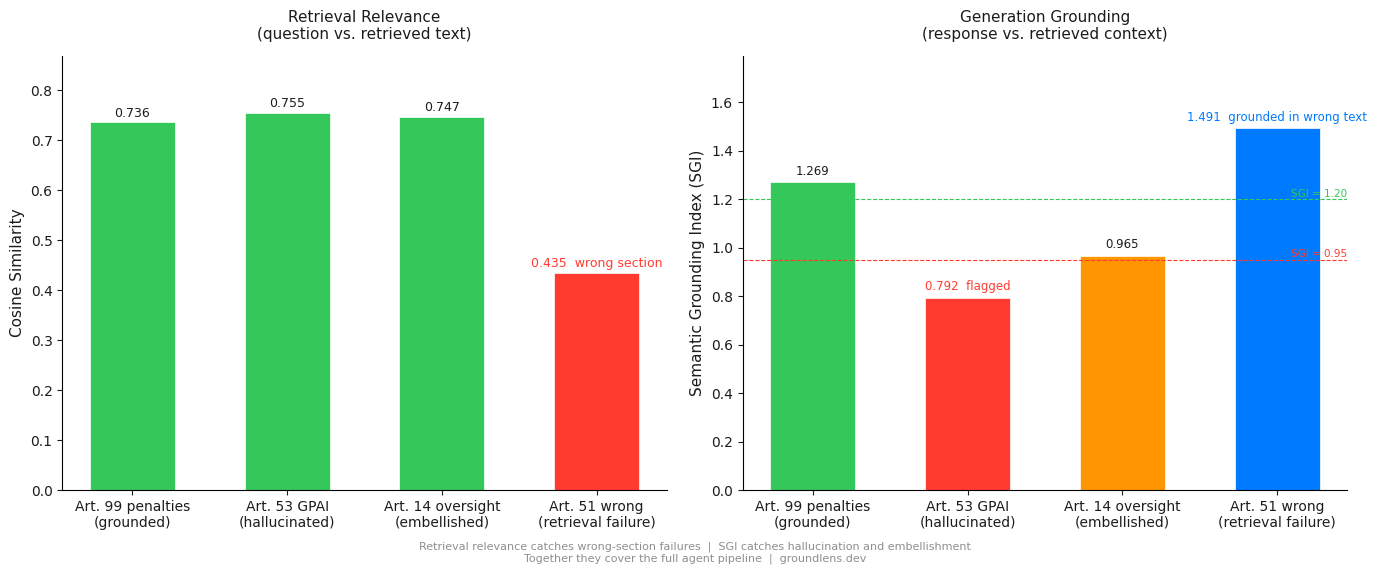

Saved: eu_ai_act_full_comparison.png


In [10]:
cases = [
    ("Art. 99 penalties\n(grounded)",      rel_1, sgi_1, False),
    ("Art. 53 GPAI\n(hallucinated)",       rel_2, sgi_2, False),
    ("Art. 14 oversight\n(embellished)",    rel_3, sgi_3, False),
    ("Art. 51 wrong\n(retrieval failure)",  rel_4, sgi_4, True),
]

APPLE_RED = "#FF3B30"
APPLE_GREEN = "#34C759"
APPLE_ORANGE = "#FF9500"
APPLE_BLUE = "#007AFF"
APPLE_TEXT = "#1C1C1E"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# -- Left: Retrieval Relevance --
labels = [c[0] for c in cases]
rels = [c[1] for c in cases]
is_wrong_retrieval = [c[3] for c in cases]

rel_colors = [APPLE_RED if wr else APPLE_GREEN for wr in is_wrong_retrieval]

bars1 = ax1.bar(labels, rels, color=rel_colors, width=0.55, edgecolor="white", linewidth=0.5)
for bar, val, wr in zip(bars1, rels, is_wrong_retrieval):
    label = f"{val:.3f}"
    if wr:
        label += "  wrong section"
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             label, ha="center", va="bottom", fontsize=9,
             color=APPLE_RED if wr else APPLE_TEXT)

ax1.set_ylabel("Cosine Similarity", fontsize=11, color=APPLE_TEXT)
ax1.set_title("Retrieval Relevance\n(question vs. retrieved text)", fontsize=11, pad=12, color=APPLE_TEXT)
ax1.set_ylim(0, max(rels) * 1.15)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.tick_params(colors=APPLE_TEXT)

# -- Right: SGI --
sgis = [c[2].value for c in cases]
flagged = [c[2].flagged for c in cases]

sgi_colors = []
for v, f, wr in zip(sgis, flagged, is_wrong_retrieval):
    if wr:
        sgi_colors.append(APPLE_BLUE)  # Special: grounded in wrong context
    elif f:
        sgi_colors.append(APPLE_RED)
    elif v < 1.20:
        sgi_colors.append(APPLE_ORANGE)
    else:
        sgi_colors.append(APPLE_GREEN)

bars2 = ax2.bar(labels, sgis, color=sgi_colors, width=0.55, edgecolor="white", linewidth=0.5)
ax2.axhline(y=0.95, color=APPLE_RED, linestyle="--", linewidth=0.8)
ax2.axhline(y=1.20, color=APPLE_GREEN, linestyle="--", linewidth=0.8)
ax2.text(3.45, 0.96, "SGI = 0.95", fontsize=7.5, color=APPLE_RED, ha="right")
ax2.text(3.45, 1.21, "SGI = 1.20", fontsize=7.5, color=APPLE_GREEN, ha="right")

for bar, val, f, wr in zip(bars2, sgis, flagged, is_wrong_retrieval):
    label = f"{val:.3f}"
    if wr:
        label += "  grounded in wrong text"
    elif f:
        label += "  flagged"
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             label, ha="center", va="bottom", fontsize=8.5,
             color=APPLE_BLUE if wr else (APPLE_RED if f else APPLE_TEXT))

ax2.set_ylabel("Semantic Grounding Index (SGI)", fontsize=11, color=APPLE_TEXT)
ax2.set_title("Generation Grounding\n(response vs. retrieved context)", fontsize=11, pad=12, color=APPLE_TEXT)
ax2.set_ylim(0, max(sgis) * 1.2)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.tick_params(colors=APPLE_TEXT)

fig.text(0.5, -0.03,
    "Retrieval relevance catches wrong-section failures  |  SGI catches hallucination and embellishment\n"
    "Together they cover the full agent pipeline  |  groundlens.dev",
    ha="center", fontsize=8, color="#8E8E93")

plt.tight_layout()
plt.savefig("eu_ai_act_full_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eu_ai_act_full_comparison.png")

## 9. Pipeline Gauge Visualization

Each case shown as a 2-step pipeline: retriever (relevance) then analyzer (SGI). The gauges use raw metric scales with empirically derived zone boundaries.

In [11]:
def draw_pipeline_gauges(title, steps, question, answer):
    """Draw pipeline with gauge bars for each step."""
    APPLE_RED = "#FF3B30"
    APPLE_ORANGE = "#FF9500"
    APPLE_GREEN = "#34C759"
    APPLE_BLUE = "#007AFF"
    APPLE_TEXT = "#1C1C1E"

    n = len(steps)
    fig_height = 1.6 + n * 1.4 + 1.2
    fig, ax = plt.subplots(figsize=(11, fig_height))
    ax.set_xlim(0, 11)
    ax.set_ylim(0, fig_height)
    ax.axis("off")

    y = fig_height - 0.3
    ax.text(5.5, y, title, fontsize=13, ha="center", va="top", color=APPLE_TEXT)
    y -= 0.5

    q_text = question if len(question) < 90 else question[:87] + "..."
    a_text = answer if len(answer) < 90 else answer[:87] + "..."
    ax.text(0.3, y, f"Q: {q_text}", fontsize=11, va="top", color=APPLE_TEXT)
    y -= 0.4
    ax.text(0.3, y, f"A: {a_text}", fontsize=10, va="top", color=APPLE_TEXT)
    y -= 0.7

    for step in steps:
        metric = step["metric"]
        value = step["value"]
        triage = step["triage"]
        node = step["node"]

        if metric == "relevance":
            g_min, g_max = 0.0, 1.0
            t1, t2 = 0.3, 0.5
            metric_label = f"REL={value:.3f}"
        elif metric == "sgi":
            g_min, g_max = 0.30, 2.50
            t1, t2 = 0.95, 1.20
            metric_label = f"SGI={value:.3f}"
        else:
            g_min, g_max = -1.0, 1.0
            t1, t2 = 0.0, 0.30
            metric_label = f"DGI={value:.3f}"

        if triage == "flagged":
            icon, node_color = "\u2717", APPLE_RED
        elif triage == "review":
            icon, node_color = "\u26a0", APPLE_ORANGE
        else:
            icon, node_color = "\u2713", APPLE_GREEN

        ax.text(0.3, y, f"{icon} {node}", fontsize=10, va="center", color=node_color)
        ax.text(2.8, y, metric_label, fontsize=10, va="center", color=APPLE_TEXT)

        gx, gw, gh = 4.2, 6.2, 0.35
        gy = y - gh / 2

        def x_for(v, _gmin=g_min, _gmax=g_max, _gx=gx, _gw=gw):
            return _gx + (v - _gmin) / (_gmax - _gmin) * _gw

        ax.add_patch(mpatches.FancyBboxPatch(
            (gx, gy), x_for(t1) - gx, gh,
            boxstyle="round,pad=0", facecolor=APPLE_RED, edgecolor="none"))
        ax.add_patch(mpatches.FancyBboxPatch(
            (x_for(t1), gy), x_for(t2) - x_for(t1), gh,
            boxstyle="round,pad=0", facecolor=APPLE_ORANGE, edgecolor="none"))
        ax.add_patch(mpatches.FancyBboxPatch(
            (x_for(t2), gy), gx + gw - x_for(t2), gh,
            boxstyle="round,pad=0", facecolor=APPLE_GREEN, edgecolor="none"))

        for tv in [t1, t2]:
            tx = x_for(tv)
            ax.plot([tx, tx], [gy - 0.06, gy + gh + 0.06], color=APPLE_TEXT, linewidth=0.7)
            ax.text(tx, gy - 0.1, f"{tv}", fontsize=6.5, ha="center", va="top", color=APPLE_TEXT)

        ax.text(gx, gy - 0.1, f"{g_min}", fontsize=6.5, ha="center", va="top", color="#8E8E93")
        ax.text(gx + gw, gy - 0.1, f"{g_max}", fontsize=6.5, ha="center", va="top", color="#8E8E93")

        zone_y = y
        ax.text((gx + x_for(t1)) / 2, zone_y, "flagged", fontsize=6.5,
                ha="center", va="center", color="white")
        ax.text((x_for(t1) + x_for(t2)) / 2, zone_y, "\u26a0 review", fontsize=6.5,
                ha="center", va="center", color="white")
        ax.text((x_for(t2) + gx + gw) / 2, zone_y, "trusted", fontsize=6.5,
                ha="center", va="center", color="white")

        vx = x_for(min(max(value, g_min), g_max))
        tri_y = gy + gh + 0.08
        triangle = plt.Polygon(
            [[vx - 0.08, tri_y + 0.12], [vx + 0.08, tri_y + 0.12], [vx, tri_y]],
            closed=True, facecolor=APPLE_TEXT, edgecolor="none")
        ax.add_patch(triangle)

        y -= 1.4

    plt.tight_layout()
    return fig

print("draw_pipeline_gauges() defined")

draw_pipeline_gauges() defined


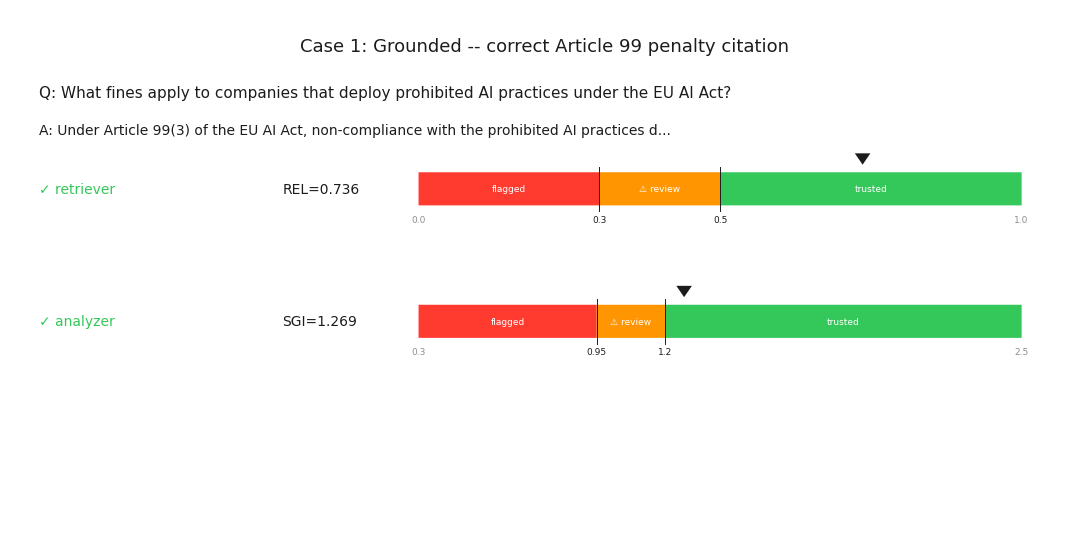

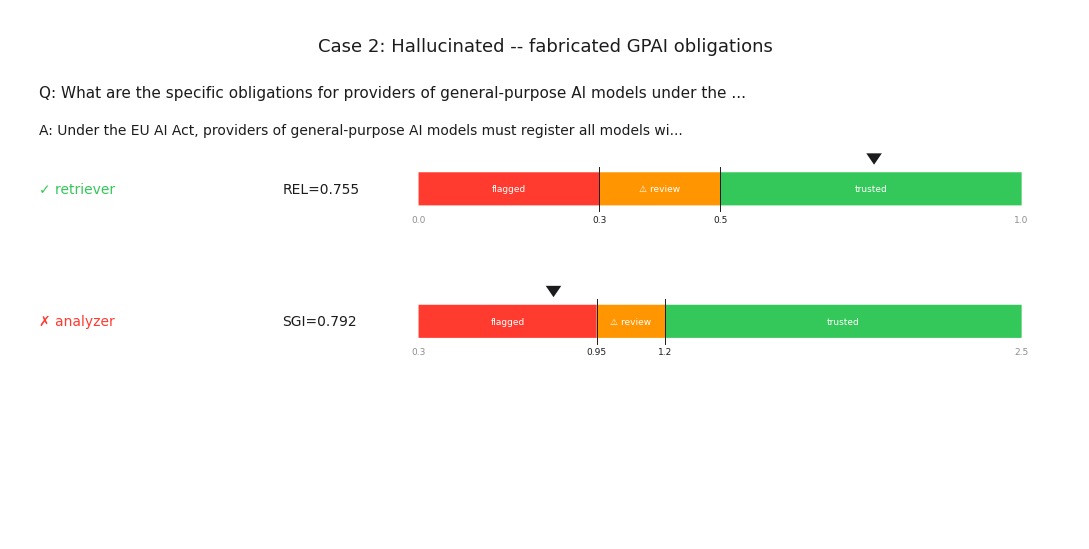

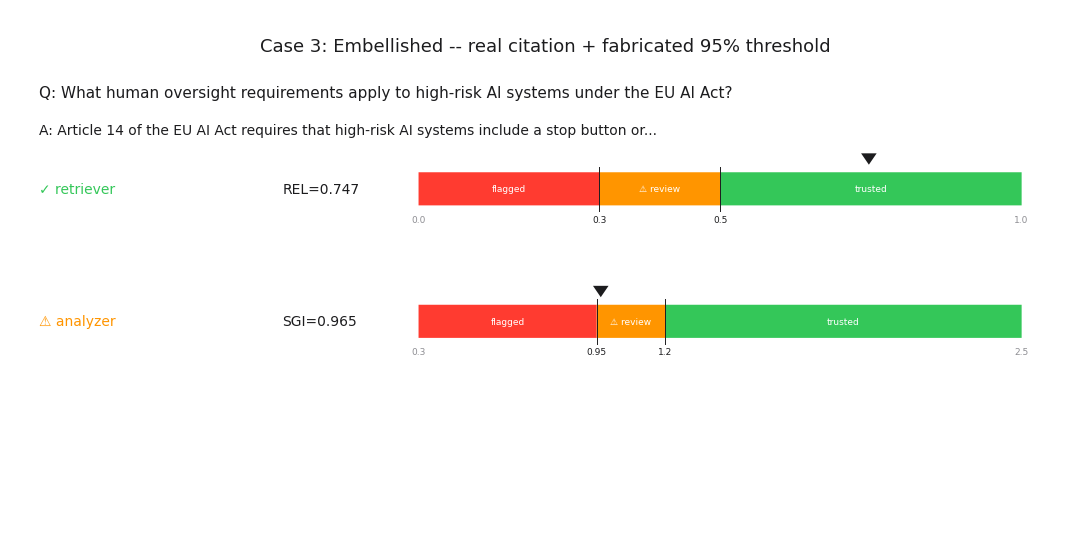

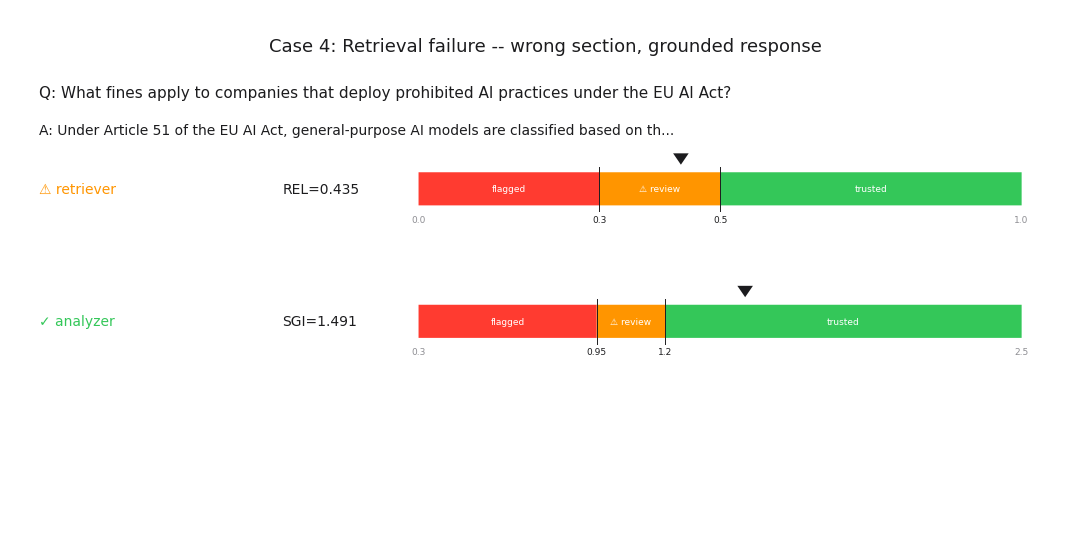

In [12]:
# -- Helper: classify relevance --
def rel_triage(r):
    if r < 0.3: return "flagged"
    if r < 0.5: return "review"
    return "trusted"

def sgi_triage(s):
    if s.flagged: return "flagged"
    if s.value < 1.20: return "review"
    return "trusted"

# Case 1: Grounded
draw_pipeline_gauges(
    "Case 1: Grounded -- correct Article 99 penalty citation",
    [
        {"node": "retriever", "metric": "relevance", "value": rel_1, "triage": rel_triage(rel_1)},
        {"node": "analyzer",  "metric": "sgi",       "value": sgi_1.value, "triage": sgi_triage(sgi_1)},
    ],
    Q1, R1[:87] + "...",
)
plt.savefig("gauge_case1.png", dpi=150, bbox_inches="tight")
plt.show()

# Case 2: Hallucinated
draw_pipeline_gauges(
    "Case 2: Hallucinated -- fabricated GPAI obligations",
    [
        {"node": "retriever", "metric": "relevance", "value": rel_2, "triage": rel_triage(rel_2)},
        {"node": "analyzer",  "metric": "sgi",       "value": sgi_2.value, "triage": sgi_triage(sgi_2)},
    ],
    Q2, R2[:87] + "...",
)
plt.savefig("gauge_case2.png", dpi=150, bbox_inches="tight")
plt.show()

# Case 3: Embellished
draw_pipeline_gauges(
    "Case 3: Embellished -- real citation + fabricated 95% threshold",
    [
        {"node": "retriever", "metric": "relevance", "value": rel_3, "triage": rel_triage(rel_3)},
        {"node": "analyzer",  "metric": "sgi",       "value": sgi_3.value, "triage": sgi_triage(sgi_3)},
    ],
    Q3, R3[:87] + "...",
)
plt.savefig("gauge_case3.png", dpi=150, bbox_inches="tight")
plt.show()

# Case 4: Retrieval failure
draw_pipeline_gauges(
    "Case 4: Retrieval failure -- wrong section, grounded response",
    [
        {"node": "retriever", "metric": "relevance", "value": rel_4, "triage": rel_triage(rel_4)},
        {"node": "analyzer",  "metric": "sgi",       "value": sgi_4.value, "triage": sgi_triage(sgi_4)},
    ],
    Q4, R4[:87] + "...",
)
plt.savefig("gauge_case4.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Failure Mode Matrix

In [13]:
# Print the full failure mode matrix
print(f"{'Case':<35} {'Retrieval':>10} {'SGI':>8} {'Retrieval':>12} {'Generation':>12} {'Caught by':>15}")
print(f"{'':<35} {'Relevance':>10} {'':>8} {'Status':>12} {'Status':>12} {'':>15}")
print("-" * 95)

matrix = [
    ("1. Grounded",            rel_1, sgi_1.value, sgi_1.flagged, False),
    ("2. Hallucinated",        rel_2, sgi_2.value, sgi_2.flagged, False),
    ("3. Embellished",         rel_3, sgi_3.value, sgi_3.flagged, False),
    ("4. Retrieval failure",   rel_4, sgi_4.value, sgi_4.flagged, True),
]

for name, rel, sgi_val, sgi_flag, wrong_ret in matrix:
    ret_status = "wrong" if wrong_ret else "correct"
    gen_status = "flagged" if sgi_flag else ("review" if sgi_val < 1.20 else "trusted")
    if wrong_ret:
        caught = "relevance"
    elif sgi_flag:
        caught = "SGI"
    elif sgi_val < 1.20:
        caught = "SGI (review)"
    else:
        caught = "-- (correct)"
    print(f"{name:<35} {rel:>10.4f} {sgi_val:>8.3f} {ret_status:>12} {gen_status:>12} {caught:>15}")

Case                                 Retrieval      SGI    Retrieval   Generation       Caught by
                                     Relevance                Status       Status                
-----------------------------------------------------------------------------------------------
1. Grounded                             0.7363    1.269      correct      trusted    -- (correct)
2. Hallucinated                         0.7553    0.792      correct      flagged             SGI
3. Embellished                          0.7467    0.965      correct       review    SGI (review)
4. Retrieval failure                    0.4350    1.491        wrong      trusted       relevance


---

## Summary

### Two metrics, full pipeline coverage

| Failure mode | Retrieval relevance | SGI | Detection |
|---|---|---|---|
| Correct answer | High | > 1.20 (trusted) | No alert needed |
| Hallucination (LLM fabricates) | High | < 0.95 (flagged) | SGI catches it |
| Embellishment (mix real + invented) | High | 0.95--1.20 (review) | SGI escalates for review |
| Retrieval failure (wrong section) | Low | High (grounded in wrong text) | Relevance catches it |

**SGI alone has a blind spot:** when the retriever pulls the wrong section, the LLM can ground perfectly in the wrong text, and SGI sees nothing wrong. Retrieval relevance closes that gap.

### The autonomous agent verification layer

As organizations deploy AI agents with document access -- Claude Desktop reading contracts via MCP, LangGraph pipelines processing compliance documents, CrewAI crews answering regulatory questions -- the need for automated verification scales with autonomy.

A human can't review every response from an agent that processes hundreds of documents per day. groundlens provides the triage signal at every pipeline step: which retrievals are relevant, which generations are grounded, and which need human verification.

### Links

- **GitHub:** [github.com/groundlens-dev/groundlens](https://github.com/groundlens-dev/groundlens)
- **Docs:** [groundlens.dev](https://groundlens.dev)
- **Paper (SGI):** [arXiv:2512.13771](https://arxiv.org/abs/2512.13771)
- **Paper (Taxonomy):** [arXiv:2602.13224](https://arxiv.org/abs/2602.13224)